
## 3.1 Understanding the dataset
1. Import the dataset in a notebook environment with python library: “Pandas”
2. Show the number of attributes (columns) and number of records (rows)
3. Show the statistics of the dataset (column wise mean, standard deviation, max, min etc).
You can use Matplotlib, to visualize the distribution of data.
4. Count the number of missing values in the dataset
5. Count the number of duplicate values in the dataset.

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(42)


In [2]:
# Step 2: Load the dataset and Show number of rows and columns
url = "https://docs.google.com/spreadsheets/d/1sQgs550vWZPifj0j_HJ-i0WrbXo_MDI8Vgmm0IwJCJI/export?format=csv&gid=1996190875"
dataframe_real = pd.read_csv(url)

In [88]:
dataframe = dataframe_real.copy()
dataframe.head()  # Display first few rows

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No


In [89]:
dataframe.dtypes

Student ID        float64
Age               float64
Gender             object
Height            float64
Weight            float64
Blood Type         object
BMI               float64
Temperature       float64
Heart Rate        float64
Blood Pressure    float64
Cholesterol       float64
Diabetes           object
Smoking            object
dtype: object

In [90]:
dataframe.shape  # (number of rows, number of columns)

(200000, 13)

In [91]:
dataframe.columns.tolist()

['Student ID',
 'Age',
 'Gender',
 'Height',
 'Weight',
 'Blood Type',
 'BMI',
 'Temperature',
 'Heart Rate',
 'Blood Pressure',
 'Cholesterol',
 'Diabetes',
 'Smoking']

In [92]:
# Step 3: Show column-wise statistics
dataframe.describe()  # mean, std, min, max, etc.

,Student ID,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,49974.042078,26.021561,174.947103,69.971585,23.338869,98.600948,79.503767,114.558033,184.486361
std,28879.641657,4.890528,14.447560,17.322574,7.033554,0.500530,11.540755,14.403353,37.559678
min,1.000000,18.000000,150.000041,40.000578,10.074837,96.397835,60.000000,90.000000,120.000000
25%,24971.750000,22.000000,162.476110,54.969838,17.858396,98.264750,70.000000,102.000000,152.000000
50%,49943.500000,26.000000,174.899914,69.979384,22.671401,98.599654,80.000000,115.000000,184.000000
75%,74986.000000,30.000000,187.464417,84.980097,27.997487,98.940543,90.000000,127.000000,217.000000
max,100000.000000,34.000000,199.998639,99.999907,44.355113,100.824857,99.000000,139.000000,249.000000


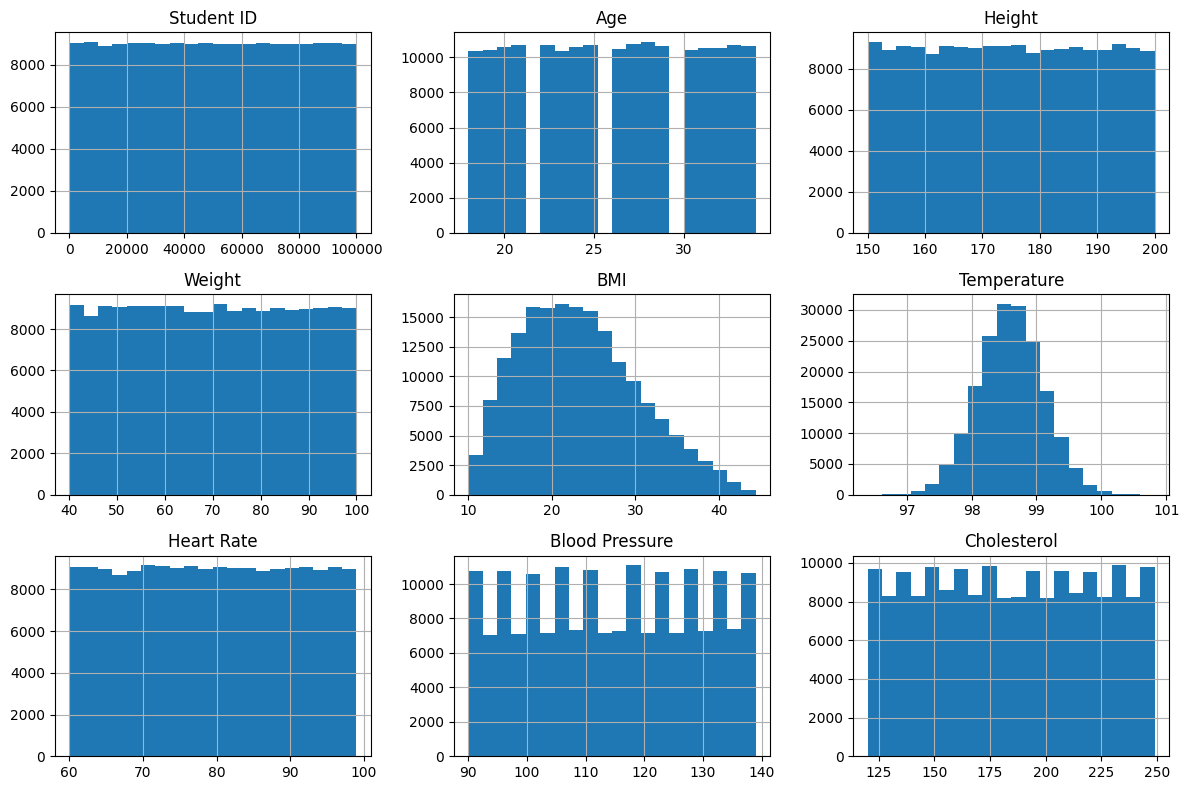

In [93]:
num_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
dataframe[num_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

In [94]:
num_cols

['Student ID',
 'Age',
 'Height',
 'Weight',
 'BMI',
 'Temperature',
 'Heart Rate',
 'Blood Pressure',
 'Cholesterol']

In [95]:
# Step 4: Count missing values
dataframe.isnull().sum()

Student ID        20000
Age               20000
Gender            20000
Height            20000
Weight            20000
Blood Type        20000
BMI               20000
Temperature       20000
Heart Rate        20000
Blood Pressure    20000
Cholesterol       20000
Diabetes          20000
Smoking           20000
dtype: int64

In [100]:
# Step 5: Count duplicate rows
dataframe.duplicated().sum()

np.int64(7644)

In [101]:
dataframe[dataframe.duplicated()]

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
100007,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,No,No
100011,12.0,34.0,Female,182.416302,76.371050,AB,22.950992,98.118274,86.0,97.0,247.0,No,No
100018,19.0,31.0,Female,158.790160,46.829849,AB,18.572723,98.784709,92.0,102.0,172.0,NaN,No
100022,23.0,29.0,Female,179.909041,90.679436,AB,28.015787,98.782269,81.0,108.0,227.0,No,Yes
100023,24.0,18.0,Male,NaN,52.521560,AB,13.570402,98.215090,60.0,132.0,217.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199961,99962.0,31.0,Male,180.859321,43.647709,B,13.343804,98.675411,68.0,90.0,223.0,No,No
199962,99963.0,18.0,Female,180.133710,48.381499,A,14.910401,98.104064,71.0,129.0,184.0,No,No
199965,99966.0,22.0,Female,166.562901,48.684146,AB,17.548137,98.776134,95.0,109.0,152.0,Yes,No
199973,99974.0,25.0,Female,156.297842,90.690186,B,37.123963,98.664591,70.0,132.0,164.0,Yes,No


In [102]:
dataframe[dataframe.duplicated(keep=False)].shape  

(15288, 13)

## 3.2 Data cleaning
1. If you find any missing values in the dataset (NaN values) replace those data with the column
wise mean.
2. If you find any duplicates in the dataset, keep just one copy of the data.
3. Remember, if any row in the target column (Diabetes) is missing, you must drop that row

In [103]:
dataframe.drop_duplicates(inplace=True)

In [104]:
dataframe.duplicated().sum()

np.int64(0)

In [105]:
# Drop the rows where the target is null
dataframe.dropna(subset=['Diabetes'], inplace=True)

In [106]:
dataframe.drop(columns=['Student ID'], inplace=True)

In [107]:
dataframe.columns.tolist()

['Age',
 'Gender',
 'Height',
 'Weight',
 'Blood Type',
 'BMI',
 'Temperature',
 'Heart Rate',
 'Blood Pressure',
 'Cholesterol',
 'Diabetes',
 'Smoking']

In [108]:
# Step 1: Fill missing values in numeric columns with column-wise mean
dataframe.fillna(dataframe.mean(numeric_only=True), inplace=True)

In [109]:
categorical_columns = ['Blood Type', 'Smoking', 'Gender']
for col in categorical_columns:
    dataframe[col] = dataframe[col].fillna(dataframe[col].mode()[0])

In [110]:
dataframe.isnull().sum()

Age               0
Gender            0
Height            0
Weight            0
Blood Type        0
BMI               0
Temperature       0
Heart Rate        0
Blood Pressure    0
Cholesterol       0
Diabetes          0
Smoking           0
dtype: int64

In [111]:
dataframe.shape

(172451, 12)

## 3.3 Creation of input and output features
You need to split the data into two parts. The “Features” variable will consist of all the columns
in the dataset except the target column. And the “Labels” variable will contain only the target
column.

In [112]:
# Create Features and Labels
Features = dataframe.drop(columns=['Diabetes'])  # all columns except target
Labels = dataframe['Diabetes']                   # only the target column

In [113]:
Features

,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Smoking
0,18.000000,Female,161.777924,72.354947,O,27.645835,98.601226,95.0,109.000000,203.000000,No
1,26.028614,Male,152.069157,47.630941,B,23.347349,98.714977,93.0,104.000000,163.000000,No
2,32.000000,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.000000,216.000000,No
3,30.000000,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.000000,141.000000,Yes
4,23.000000,Female,174.948041,46.234173,O,23.347349,98.480008,95.0,114.564417,231.000000,No
...,...,...,...,...,...,...,...,...,...,...,...
199993,22.000000,Male,174.948041,46.155224,A,23.347349,98.331019,93.0,100.000000,184.493074,No
199994,22.000000,Male,159.486907,70.004026,A,27.631082,98.971976,86.0,134.000000,208.000000,No
199995,24.000000,Male,176.503260,95.756997,B,30.737254,99.170685,65.0,121.000000,130.000000,No
199996,29.000000,Female,163.917675,45.225194,O,16.831734,97.865785,62.0,125.000000,198.000000,Yes


In [114]:
Labels

0          No
1          No
2         Yes
3          No
4          No
         ... 
199993    Yes
199994     No
199995     No
199996     No
199998     No
Name: Diabetes, Length: 172451, dtype: object

## 3.4 Conversion of features into numeric values
1. You will notice that a number of columns in the dataset contains text (string type) features.
For example, the target column also contains labels in the form: “Yes”/ “No”. You first need
to convert these columns into numeric features.
2. For doing that, you need to first convert such columns which are not numeric types, into
categorical types. Then you need to perform one hot encoding on that column, which will
divide that column into multiple one hot type column. To better understand this approach,
follow this link: get dummies in pandas. (You can use library function here)
3. Remember that, you could have performed label encoding (Label Encoding) instead of one
hot encoding. However, giving strict numeric values to some labels might create a bias. For
example, if you convert a column ‘Blood Type’ like this:
O → 0
A → 1
B → 2
This might create a bias in the model to give the blood group B greater value. However, if
there are only 2 different values in a column, you can perform label encoding instead of one
hot. This will reduce the number of new columns.

In [115]:
Features.dtypes

Age               float64
Gender             object
Height            float64
Weight            float64
Blood Type         object
BMI               float64
Temperature       float64
Heart Rate        float64
Blood Pressure    float64
Cholesterol       float64
Smoking            object
dtype: object

In [116]:
Features.isnull().sum()

Age               0
Gender            0
Height            0
Weight            0
Blood Type        0
BMI               0
Temperature       0
Heart Rate        0
Blood Pressure    0
Cholesterol       0
Smoking           0
dtype: int64

In [117]:
# Convert each column to categorical type
for col in categorical_columns:
    Features[col] = Features[col].astype('category')

In [118]:
Features.dtypes

Age                float64
Gender            category
Height             float64
Weight             float64
Blood Type        category
BMI                float64
Temperature        float64
Heart Rate         float64
Blood Pressure     float64
Cholesterol        float64
Smoking           category
dtype: object

In [119]:
# One-hot encode the data using pandas get_dummies
Features = pd.get_dummies(Features)

In [120]:
Features

,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Female,Gender_Male,Blood Type_A,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_No,Smoking_Yes
0,18.000000,161.777924,72.354947,27.645835,98.601226,95.0,109.000000,203.000000,True,False,False,False,False,True,True,False
1,26.028614,152.069157,47.630941,23.347349,98.714977,93.0,104.000000,163.000000,False,True,False,False,True,False,True,False
2,32.000000,182.537664,55.741083,16.729017,98.260293,76.0,130.000000,216.000000,True,False,True,False,False,False,True,False
3,30.000000,182.112867,63.332207,19.096042,98.839605,99.0,112.000000,141.000000,False,True,False,False,True,False,False,True
4,23.000000,174.948041,46.234173,23.347349,98.480008,95.0,114.564417,231.000000,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199993,22.000000,174.948041,46.155224,23.347349,98.331019,93.0,100.000000,184.493074,False,True,True,False,False,False,True,False
199994,22.000000,159.486907,70.004026,27.631082,98.971976,86.0,134.000000,208.000000,False,True,True,False,False,False,True,False
199995,24.000000,176.503260,95.756997,30.737254,99.170685,65.0,121.000000,130.000000,False,True,False,False,True,False,True,False
199996,29.000000,163.917675,45.225194,16.831734,97.865785,62.0,125.000000,198.000000,True,False,False,False,False,True,False,True


In [121]:
Features.dtypes

Age               float64
Height            float64
Weight            float64
BMI               float64
Temperature       float64
Heart Rate        float64
Blood Pressure    float64
Cholesterol       float64
Gender_Female        bool
Gender_Male          bool
Blood Type_A         bool
Blood Type_AB        bool
Blood Type_B         bool
Blood Type_O         bool
Smoking_No           bool
Smoking_Yes          bool
dtype: object

In [122]:
Features.isnull().sum()

Age               0
Height            0
Weight            0
BMI               0
Temperature       0
Heart Rate        0
Blood Pressure    0
Cholesterol       0
Gender_Female     0
Gender_Male       0
Blood Type_A      0
Blood Type_AB     0
Blood Type_B      0
Blood Type_O      0
Smoking_No        0
Smoking_Yes       0
dtype: int64

In [123]:
Labels

0          No
1          No
2         Yes
3          No
4          No
         ... 
199993    Yes
199994     No
199995     No
199996     No
199998     No
Name: Diabetes, Length: 172451, dtype: object

In [124]:
from sklearn.preprocessing import LabelEncoder

In [125]:
encoder = LabelEncoder()
Labels = encoder.fit_transform(Labels)

In [126]:
Labels

array([0, 0, 1, ..., 0, 0, 0], shape=(172451,))

In [127]:
Features.shape

(172451, 16)

## 3.5 Scaling of the features
1. You will see in the dataset that, the ranges of values in a column varies significantly with the
values range from a different column. This will surely hamper the training process of the ML
model. To resolve this issue, we apply scaling.
2. There are two types of scaling you can perform: StandardScaling and MinMaxScaling. You
need to perform both type of scaling on the dataset and verify which works well (It is expected
you do this in a functional way, so whenever you prefer one scaling over another, you can
simply change your preference in the argument of this scaling function).
Standard Scaling (Z-score normalization) transforms features so that they have a mean of
0 and a standard deviation of 1.
Min-Max Scaling (also known as normalization) scales the data to a fixed range, typically
between 0 and 1.
(You can use library function here)
3. Remember, never scale the target variable. Only scale the feature variables. Please note that,
you should avoid scaling the one hot type column that you get in Section 3.4(2). They are
already scaled between zero and one.

In [128]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [129]:
def scale_features(df, numeric_cols, method='standard'):
    """
    df: DataFrame of features
    numeric_cols: list of numeric columns to scale
    method: 'standard' for StandardScaler, 'minmax' for MinMaxScaler
    """
    df_scaled = df.copy()
    
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("method must be 'standard' or 'minmax'")
    
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
    return df_scaled


In [130]:
numeric_cols = Features.select_dtypes(include=['float64']).columns.tolist()
numeric_cols

['Age',
 'Height',
 'Weight',
 'BMI',
 'Temperature',
 'Heart Rate',
 'Blood Pressure',
 'Cholesterol']

In [131]:
# Standard scaling
Features_standard = scale_features(Features, numeric_cols, method='standard')
Features_standard

,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Female,Gender_Male,Blood Type_A,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_No,Smoking_Yes
0,-1.733084,-9.626660e-01,1.433476e-01,0.645628,0.000000,1.418159,-0.407649,0.520270,True,False,False,False,False,True,True,False
1,0.000000,-1.672326e+00,-1.364200e+00,0.000000,0.240237,1.235115,-0.773949,-0.604217,False,True,False,False,True,False,True,False
2,1.289004,5.547613e-01,-8.696839e-01,-0.994066,-0.720034,-0.320759,1.130810,0.885727,True,False,True,False,False,False,True,False
3,0.857277,5.237109e-01,-4.068146e-01,-0.638541,0.503446,1.784247,-0.187869,-1.222684,False,True,False,False,True,False,False,True
4,-0.653767,2.077477e-15,-1.449368e+00,0.000000,-0.256006,1.418159,0.000000,1.307410,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199993,-0.869630,2.077477e-15,-1.454182e+00,0.000000,-0.570664,1.235115,-1.066988,0.000000,False,True,True,False,False,False,True,False
199994,-0.869630,-1.130127e+00,-8.665078e-16,0.643412,0.783008,0.594461,1.423850,0.660830,False,True,True,False,False,False,True,False
199995,-0.437903,1.136782e-01,1.570289e+00,1.109955,1.202671,-1.327501,0.471470,-1.531918,False,True,False,False,True,False,True,False
199996,0.641414,-8.062615e-01,-1.510891e+00,-0.978638,-1.553216,-1.602067,0.764510,0.379709,True,False,False,False,False,True,False,True


In [132]:
# Min-Max scaling
Features_minmax = scale_features(Features, numeric_cols, method='minmax')
Features_minmax

,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Female,Gender_Male,Blood Type_A,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_No,Smoking_Yes
0,0.000000,0.235564,0.539246,0.512569,0.497714,0.897436,0.387755,0.643411,True,False,False,False,False,True,True,False
1,0.501788,0.041383,0.127174,0.387176,0.523409,0.846154,0.285714,0.333333,False,True,False,False,True,False,True,False
2,0.875000,0.650771,0.262345,0.194111,0.420702,0.410256,0.816327,0.744186,True,False,True,False,False,False,True,False
3,0.750000,0.642275,0.388865,0.263160,0.551560,1.000000,0.448980,0.162791,False,True,False,False,True,False,False,True
4,0.312500,0.498974,0.103894,0.387176,0.470333,0.897436,0.501315,0.860465,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199993,0.250000,0.498974,0.102579,0.387176,0.436678,0.846154,0.204082,0.499946,False,True,True,False,False,False,True,False
199994,0.250000,0.189743,0.500063,0.512138,0.581461,0.666667,0.897959,0.682171,False,True,True,False,False,False,True,False
199995,0.375000,0.530079,0.929284,0.602749,0.626346,0.128205,0.632653,0.077519,False,True,False,False,True,False,True,False
199996,0.687500,0.278360,0.087078,0.197107,0.331589,0.051282,0.714286,0.604651,True,False,False,False,False,True,False,True


## 3.6 Correlation Analysis
1. At this point you have “Features” that contain numeric features and a target column. You
now need to perform a correlation analysis on this processed dataset. You need to show the
correlation of every column with the target column.
2. You need to show the output result (correlation of each variable with the target column) in
the notebook. (You can use library function here)
3. You can also show a correlation matrix for visualization.
4. Select the top 10 columns that have the highest correlation with the target variable. For
each of these columns, you can perform a 1D scatter plot to see how these variables help to
understand the separation between the different classes of the target variable.

In [133]:
features_df = pd.DataFrame(Features_standard, columns=['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Gender_Male', 'Blood Type_A', 'Blood Type_AB', 'Blood Type_B', 'Blood Type_O', 'Smoking_Yes'])
# features_df = pd.DataFrame(Features_minmax)
features_df

,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Male,Blood Type_A,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_Yes
0,-1.733084,-9.626660e-01,1.433476e-01,0.645628,0.000000,1.418159,-0.407649,0.520270,False,False,False,False,True,False
1,0.000000,-1.672326e+00,-1.364200e+00,0.000000,0.240237,1.235115,-0.773949,-0.604217,True,False,False,True,False,False
2,1.289004,5.547613e-01,-8.696839e-01,-0.994066,-0.720034,-0.320759,1.130810,0.885727,False,True,False,False,False,False
3,0.857277,5.237109e-01,-4.068146e-01,-0.638541,0.503446,1.784247,-0.187869,-1.222684,True,False,False,True,False,True
4,-0.653767,2.077477e-15,-1.449368e+00,0.000000,-0.256006,1.418159,0.000000,1.307410,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199993,-0.869630,2.077477e-15,-1.454182e+00,0.000000,-0.570664,1.235115,-1.066988,0.000000,True,True,False,False,False,False
199994,-0.869630,-1.130127e+00,-8.665078e-16,0.643412,0.783008,0.594461,1.423850,0.660830,True,True,False,False,False,False
199995,-0.437903,1.136782e-01,1.570289e+00,1.109955,1.202671,-1.327501,0.471470,-1.531918,True,False,False,True,False,False
199996,0.641414,-8.062615e-01,-1.510891e+00,-0.978638,-1.553216,-1.602067,0.764510,0.379709,False,False,False,False,True,True


In [134]:
labels_df = pd.DataFrame(Labels, columns=['Diabetes'])
labels_df

,Diabetes
0,0
1,0
2,1
3,0
4,0
...,...
172446,1
172447,0
172448,0
172449,0


In [135]:
target_series = labels_df['Diabetes']
correlations = features_df.corrwith(target_series)
correlations

Age               0.002963
Height           -0.000263
Weight           -0.001232
BMI              -0.001912
Temperature       0.003741
Heart Rate        0.001936
Blood Pressure    0.002976
Cholesterol      -0.000592
Gender_Male      -0.002746
Blood Type_A     -0.000263
Blood Type_AB    -0.005424
Blood Type_B      0.003936
Blood Type_O      0.001522
Smoking_Yes      -0.004960
dtype: float64

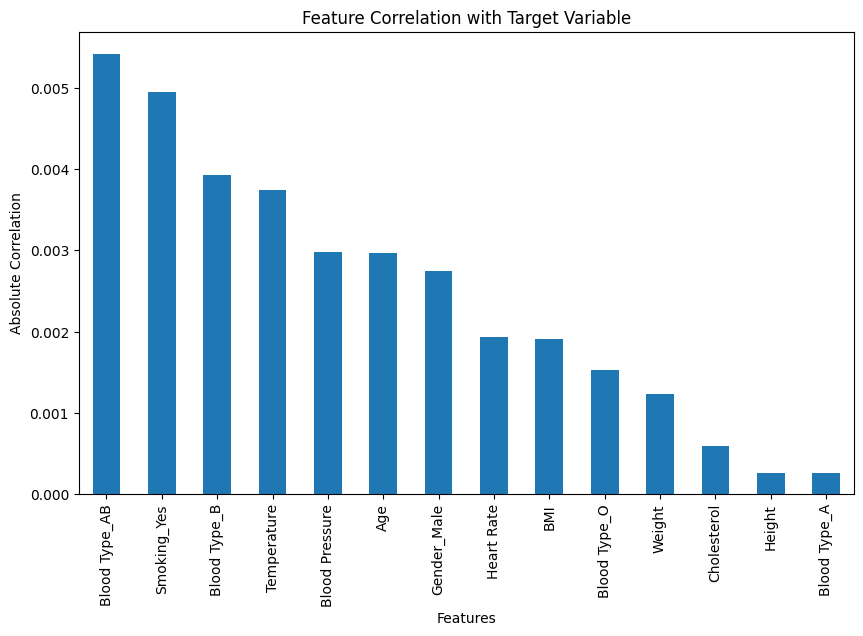

In [137]:
plt.figure(figsize=(10, 6))
correlations.abs().sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Correlation with Target Variable')
plt.ylabel('Absolute Correlation')
plt.xlabel('Features')
plt.show()

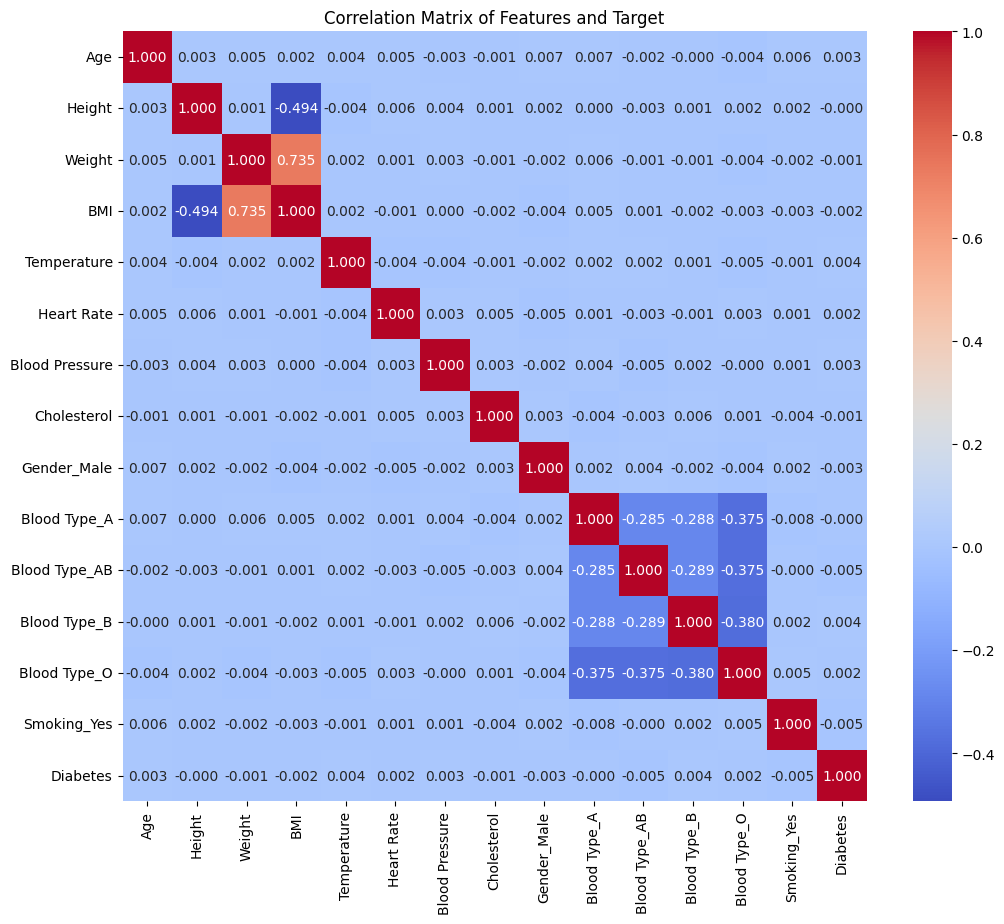

In [138]:
# Assuming features_df includes all numeric features including one-hot columns
data_for_corr = features_df.copy()
data_for_corr['Diabetes'] = labels_df['Diabetes']  

# Compute correlation matrix
corr_matrix = data_for_corr.corr()

# Plot correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix of Features and Target")
plt.show()

In [139]:
top_features = correlations.abs().sort_values(ascending=False).index
top_features

Index(['Blood Type_AB', 'Smoking_Yes', 'Blood Type_B', 'Temperature',
       'Blood Pressure', 'Age', 'Gender_Male', 'Heart Rate', 'BMI',
       'Blood Type_O', 'Weight', 'Cholesterol', 'Height', 'Blood Type_A'],
      dtype='object')

In [140]:
top10_features = top_features[:10]
top10_features

Index(['Blood Type_AB', 'Smoking_Yes', 'Blood Type_B', 'Temperature',
       'Blood Pressure', 'Age', 'Gender_Male', 'Heart Rate', 'BMI',
       'Blood Type_O'],
      dtype='object')

In [141]:
features_df = features_df[top10_features].copy()
features_df

,Blood Type_AB,Smoking_Yes,Blood Type_B,Temperature,Blood Pressure,Age,Gender_Male,Heart Rate,BMI,Blood Type_O
0,False,False,False,0.000000,-0.407649,-1.733084,False,1.418159,0.645628,True
1,False,False,True,0.240237,-0.773949,0.000000,True,1.235115,0.000000,False
2,False,False,False,-0.720034,1.130810,1.289004,False,-0.320759,-0.994066,False
3,False,True,True,0.503446,-0.187869,0.857277,True,1.784247,-0.638541,False
4,False,False,False,-0.256006,0.000000,-0.653767,False,1.418159,0.000000,True
...,...,...,...,...,...,...,...,...,...,...
199993,False,False,False,-0.570664,-1.066988,-0.869630,True,1.235115,0.000000,False
199994,False,False,False,0.783008,1.423850,-0.869630,True,0.594461,0.643412,False
199995,False,False,True,1.202671,0.471470,-0.437903,True,-1.327501,1.109955,False
199996,False,True,False,-1.553216,0.764510,0.641414,False,-1.602067,-0.978638,True


In [142]:
labels_df

,Diabetes
0,0
1,0
2,1
3,0
4,0
...,...
172446,1
172447,0
172448,0
172449,0


In [143]:
top10_features

Index(['Blood Type_AB', 'Smoking_Yes', 'Blood Type_B', 'Temperature',
       'Blood Pressure', 'Age', 'Gender_Male', 'Heart Rate', 'BMI',
       'Blood Type_O'],
      dtype='object')

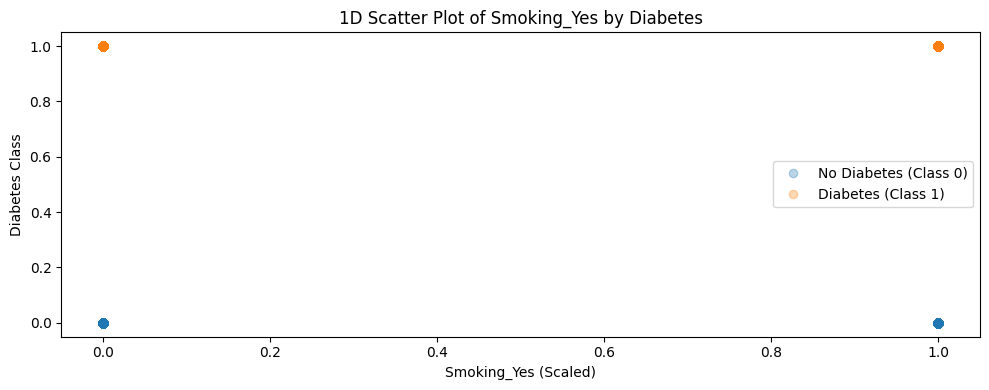

In [144]:
feature = 'Smoking_Yes'  
class_0 = features_df[labels_df["Diabetes"].values == 0]
class_1 = features_df[labels_df["Diabetes"].values == 1]

plt.figure(figsize=(10, 4))
plt.plot(class_0[feature], np.zeros_like(class_0[feature]), 'o', label='No Diabetes (Class 0)', alpha=0.3)
plt.plot(class_1[feature], np.ones_like(class_1[feature]), 'o', label='Diabetes (Class 1)', alpha=0.3)

plt.legend()
plt.xlabel(f'{feature} (Scaled)')
plt.ylabel('Diabetes Class')
plt.title(f'1D Scatter Plot of {feature} by Diabetes')
plt.tight_layout()
plt.show()

## 3.7 Validating the pipeline
1. At this stage, you should have a cleaned “Features” dataset containing the selected 10 features,
along with the corresponding target column.
2. You may now refer to the GitHub repository to review an example of training a simple
feed-forward neural network (FNN) for a classification task using PyTorch. As part of this
assignment, you are expected to design and evaluate at least “three to four” different neural
network architectures, each containing a minimum of “two to three” hidden layers. It should
be runnable on CPU, do not make the architectures too large.
3. Since the dataset is imbalanced, you must perform a stratified split to create the training,
validation, and test sets using a 70:15:15 ratio. During training, save the model that achieves
the lowest validation loss. You may use binary cross entropy loss as the loss function during
training and validation. You may use Python libraries for data split.
4. For the final selected model, evaluate its performance on the test set and report the following
metrics: accuracy, precision, F1-score and AUROC (with plot). You may use Python libraries
for calculating metrics.

In [145]:
features_df = features_df.astype(float)
features_df

,Blood Type_AB,Smoking_Yes,Blood Type_B,Temperature,Blood Pressure,Age,Gender_Male,Heart Rate,BMI,Blood Type_O
0,0.0,0.0,0.0,0.000000,-0.407649,-1.733084,0.0,1.418159,0.645628,1.0
1,0.0,0.0,1.0,0.240237,-0.773949,0.000000,1.0,1.235115,0.000000,0.0
2,0.0,0.0,0.0,-0.720034,1.130810,1.289004,0.0,-0.320759,-0.994066,0.0
3,0.0,1.0,1.0,0.503446,-0.187869,0.857277,1.0,1.784247,-0.638541,0.0
4,0.0,0.0,0.0,-0.256006,0.000000,-0.653767,0.0,1.418159,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...
199993,0.0,0.0,0.0,-0.570664,-1.066988,-0.869630,1.0,1.235115,0.000000,0.0
199994,0.0,0.0,0.0,0.783008,1.423850,-0.869630,1.0,0.594461,0.643412,0.0
199995,0.0,0.0,1.0,1.202671,0.471470,-0.437903,1.0,-1.327501,1.109955,0.0
199996,0.0,1.0,0.0,-1.553216,0.764510,0.641414,0.0,-1.602067,-0.978638,1.0


In [146]:
X = torch.tensor(features_df.values, dtype=torch.float32)
y = torch.tensor(labels_df.values, dtype=torch.float32)

# Stratified split: 70:15:15
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.17647, random_state=42, stratify=y_train_val
)  # 0.17647 ≈ 15/85

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [147]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [148]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)  
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [149]:
model0 = NeuralNet(input_size=10, hidden_size=32, num_classes=1)

In [150]:
class FNN(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super(FNN, self).__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())  # For binary classification
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [207]:
class FNN2(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super(FNN2, self).__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.Tanh())
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())  # For binary classification
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [209]:
class FNN3(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super(FNN3, self).__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.LeakyReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())  # For binary classification
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [151]:
model1 = FNN(input_size=10, hidden_sizes=[32,16])
model2 = FNN(input_size=10, hidden_sizes=[64,32])
model3 = FNN(input_size=10, hidden_sizes=[128,64,32])

In [195]:
model4 = FNN2(input_size=10, hidden_sizes=[64,32])
model5 = FNN(input_size=10, hidden_sizes=[128, 64, 32, 16])

In [210]:
model6 = FNN3(input_size=10, hidden_sizes=[64,32, 16])

In [166]:
import matplotlib.pyplot as plt
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    best_model_state = None
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0
        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_loss += criterion(model(X_batch), y_batch).item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            print("Saved Best Model at Epoch:", epoch+1)
        
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')
    
    model.load_state_dict(best_model_state)
    
    # Plot training and validation loss
    plt.figure(figsize=(8,5))
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return model

Epoch 1/100: 100%|██████████| 3773/3773 [00:01<00:00, 3087.15it/s]


Saved Best Model at Epoch: 1


Epoch 2/100: 100%|██████████| 3773/3773 [00:01<00:00, 3100.26it/s]


Saved Best Model at Epoch: 2


Epoch 3/100: 100%|██████████| 3773/3773 [00:01<00:00, 3369.36it/s]


...

Epoch 80, Train Loss: 0.3202, Validation Loss: 0.3285


Epoch 90/100: 100%|██████████| 3773/3773 [00:01<00:00, 3190.92it/s]


Epoch 90, Train Loss: 0.3201, Validation Loss: 0.3301


Epoch 100/100: 100%|██████████| 3773/3773 [00:01<00:00, 3522.79it/s]


Epoch 100, Train Loss: 0.3200, Validation Loss: 0.3290


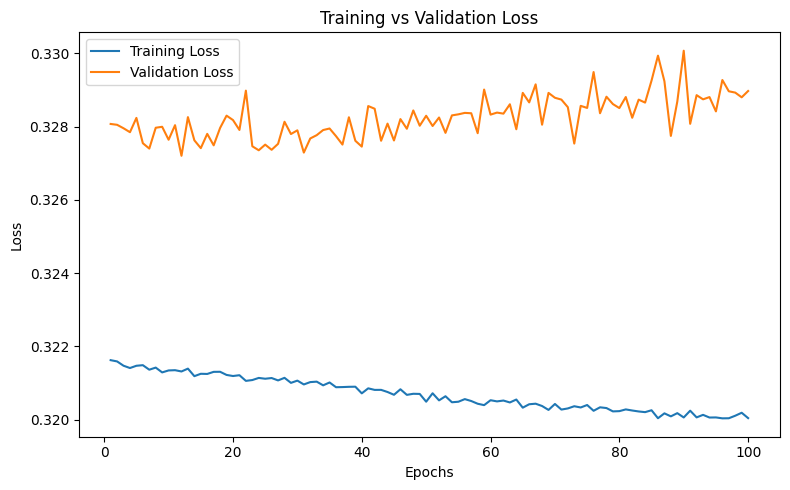

In [167]:
res_model1 = train_model(model1, train_loader, val_loader, epochs=100, lr=0.001)

Epoch 1/100: 100%|██████████| 3773/3773 [00:01<00:00, 3025.08it/s]


Saved Best Model at Epoch: 1


Epoch 5/100: 100%|██████████| 3773/3773 [00:01<00:00, 3474.21it/s]


Saved Best Model at Epoch: 5


Epoch 10/100: 100%|██████████| 3773/3773 [00:01<00:00, 3469.91it/s]


...

Epoch 80, Train Loss: 0.3151, Validation Loss: 0.3370


Epoch 90/100: 100%|██████████| 3773/3773 [00:01<00:00, 3448.17it/s]


Epoch 90, Train Loss: 0.3152, Validation Loss: 0.3361


Epoch 100/100: 100%|██████████| 3773/3773 [00:01<00:00, 3444.15it/s]


Epoch 100, Train Loss: 0.3151, Validation Loss: 0.3358


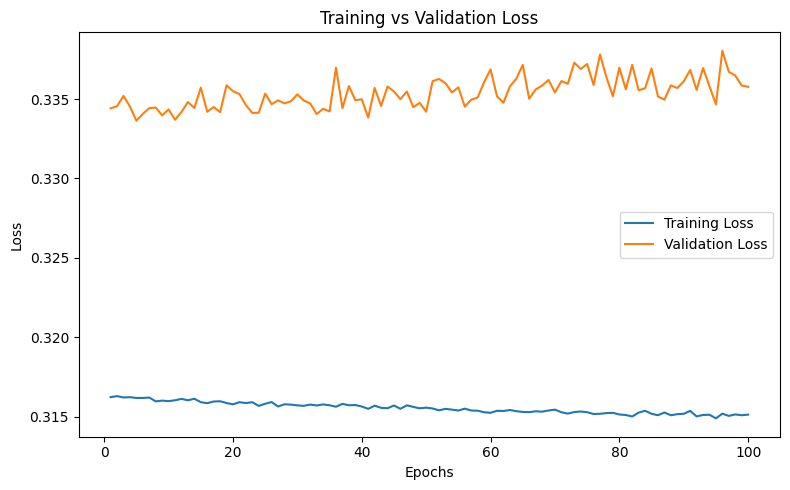

In [173]:
res_model2 = train_model(model2, train_loader, val_loader, epochs=100, lr=0.001)

Epoch 1/100: 100%|██████████| 3773/3773 [00:01<00:00, 2294.86it/s]


Saved Best Model at Epoch: 1


Epoch 2/100: 100%|██████████| 3773/3773 [00:01<00:00, 2681.29it/s]


Saved Best Model at Epoch: 2


Epoch 3/100: 100%|██████████| 3773/3773 [00:01<00:00, 2709.59it/s]


...

Epoch 80, Train Loss: 0.3000, Validation Loss: 0.3478


Epoch 90/100: 100%|██████████| 3773/3773 [00:01<00:00, 2727.04it/s]


Epoch 90, Train Loss: 0.2993, Validation Loss: 0.3548


Epoch 100/100: 100%|██████████| 3773/3773 [00:01<00:00, 2529.58it/s]


Epoch 100, Train Loss: 0.2990, Validation Loss: 0.3482


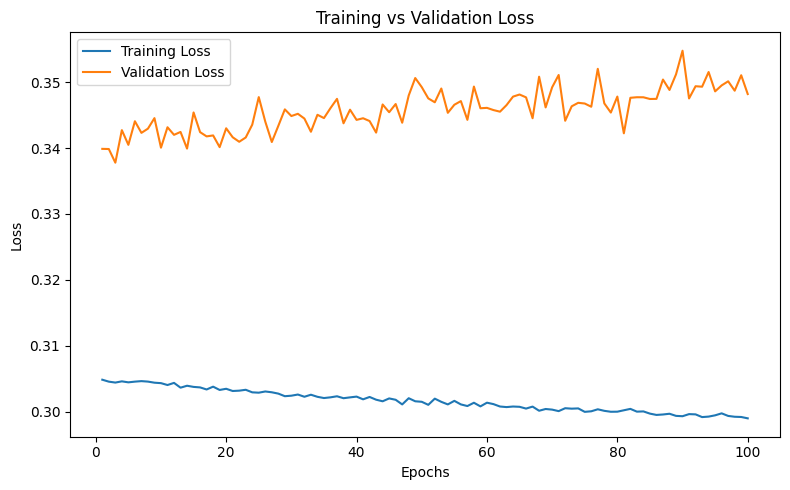

In [180]:
res_model3 = train_model(model3, train_loader, val_loader, epochs=100, lr=0.001)

Epoch 1/100: 100%|██████████| 3773/3773 [00:01<00:00, 1964.31it/s]


Saved Best Model at Epoch: 1


Epoch 2/100: 100%|██████████| 3773/3773 [00:01<00:00, 3082.59it/s]


Saved Best Model at Epoch: 2


Epoch 3/100: 100%|██████████| 3773/3773 [00:01<00:00, 3191.06it/s]


...

Epoch 80, Train Loss: 0.3161, Validation Loss: 0.3316


Epoch 90/100: 100%|██████████| 3773/3773 [00:01<00:00, 3113.66it/s]


Epoch 90, Train Loss: 0.3143, Validation Loss: 0.3324


Epoch 100/100: 100%|██████████| 3773/3773 [00:01<00:00, 3251.88it/s]


Epoch 100, Train Loss: 0.3128, Validation Loss: 0.3336


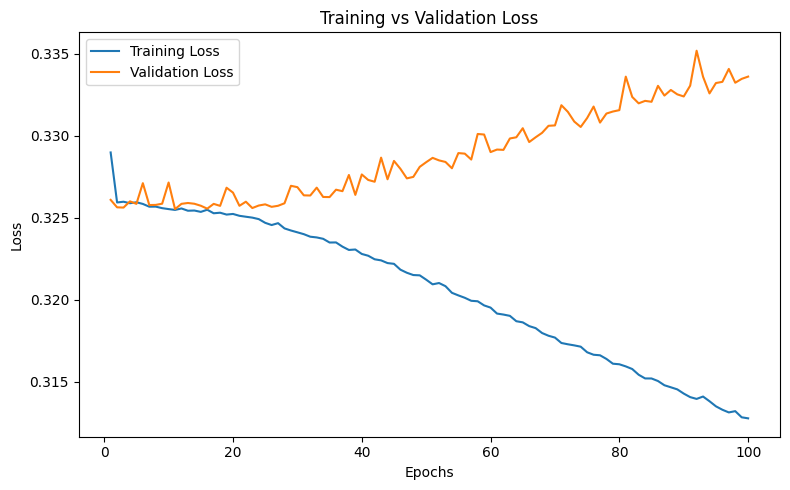

In [191]:
res_model4 = train_model(model4, train_loader, val_loader, epochs=100, lr=0.001)

Epoch 1/100: 100%|██████████| 3773/3773 [00:02<00:00, 1840.91it/s]


Saved Best Model at Epoch: 1


Epoch 2/100: 100%|██████████| 3773/3773 [00:01<00:00, 2068.46it/s]


Saved Best Model at Epoch: 2


Epoch 3/100: 100%|██████████| 3773/3773 [00:01<00:00, 2091.24it/s]


...

Epoch 80, Train Loss: 0.3068, Validation Loss: 0.3392


Epoch 90/100: 100%|██████████| 3773/3773 [00:01<00:00, 2196.04it/s]


Epoch 90, Train Loss: 0.3043, Validation Loss: 0.3397


Epoch 100/100: 100%|██████████| 3773/3773 [00:01<00:00, 2260.92it/s]


Epoch 100, Train Loss: 0.3015, Validation Loss: 0.3460


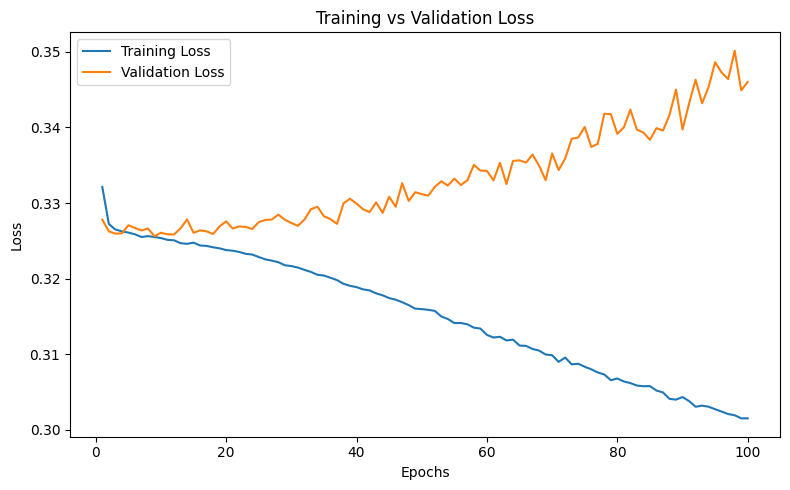

In [196]:
res_model5 = train_model(model5, train_loader, val_loader, epochs=100, lr=0.001)

Epoch 1/100: 100%|██████████| 3773/3773 [00:01<00:00, 2272.38it/s]


Saved Best Model at Epoch: 1


Epoch 2/100: 100%|██████████| 3773/3773 [00:01<00:00, 2746.02it/s]


Saved Best Model at Epoch: 2


Epoch 10/100: 100%|██████████| 3773/3773 [00:01<00:00, 2972.51it/s]


...

Epoch 80, Train Loss: 0.3146, Validation Loss: 0.3295


Epoch 90/100: 100%|██████████| 3773/3773 [00:01<00:00, 2987.84it/s]


Epoch 90, Train Loss: 0.3134, Validation Loss: 0.3314


Epoch 100/100: 100%|██████████| 3773/3773 [00:01<00:00, 2877.55it/s]


Epoch 100, Train Loss: 0.3123, Validation Loss: 0.3321


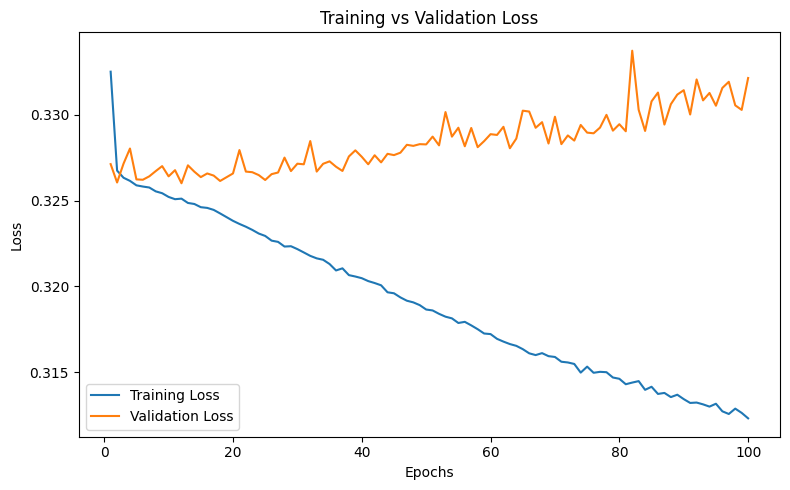

In [211]:
res_model6 = train_model(model6, train_loader, val_loader, epochs=100, lr=0.001)

In [212]:
model = res_model6
model.eval()
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        y_prob.extend(outputs.squeeze().numpy())
        preds = (outputs > 0.5).int()
        y_pred.extend(preds.squeeze().numpy())
        y_true.extend(y_batch.squeeze().numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("AUROC:", roc_auc_score(y_true, y_prob))


Accuracy: 0.8989098500077316
Precision: 0.19444444444444445
F1 Score: 0.005325218714340053
AUROC: 0.5452891470591525


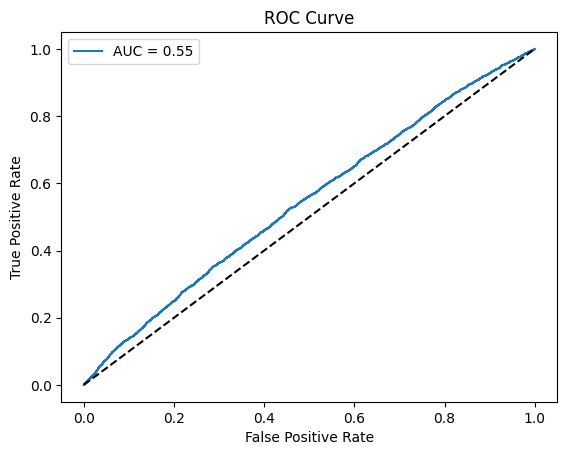

In [213]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_prob):.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

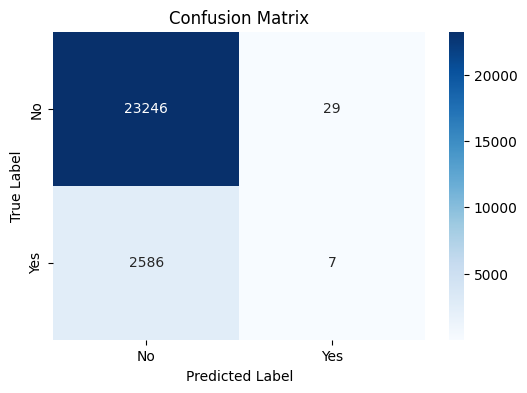

In [214]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()